In [ ]:
!unzip -q "/content/drive/MyDrive/Conglomerate Concrete Crack Detection.zip"

replace Conglomerate Concrete Crack Detection/Test/images/CFD_001.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
import tensorflow as tf
import os

def load_image_mask(image_path, mask_path):

    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels = 3)
    image = tf.image.resize(image, (256, 256))
    image = tf.cast(image, tf.float32) / 255

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels = 1)
    mask = tf.image.resize(mask, (256, 256))
    mask = tf.cast(mask, tf.float32) / 255

    return image,mask
def augmentation(image,mask):
    if tf.random.uniform(())>0.5:
        image=tf.image.flip_left_right(image)
        mask=tf.image.flip_left_right(mask)


    if tf.random.uniform(())>0.5:
        image=tf.image.flip_up_down(image)
        mask=tf.image.flip_up_down(mask)


    if tf.random.uniform(())>0.5:
        image=tf.image.random_brightness(image,max_delta=0.1)


    if tf.random.uniform(())>0.5:
        image=tf.image.random_contrast(image,lower=0.9,upper=1.1)


    return image,mask

In [ ]:
def create_dataset(image_dir, mask_dir, batch_size=16,augment_data=True):

    image_paths = sorted([os.path.join(image_dir, fname) for fname in os.listdir(image_dir)])
    mask_paths = sorted([os.path.join(mask_dir, fname) for fname in os.listdir(mask_dir)])

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    dataset = dataset.map(load_image_mask, num_parallel_calls=tf.data.AUTOTUNE)

    if augment_data:
        dataset=dataset.map(augmentation,num_parallel_calls=tf.data.AUTOTUNE)

    dataset=dataset.batch(batch_size)
    dataset=dataset.shuffle(buffer_size=1000) if augment_data else dataset
    dataset=dataset.prefetch(tf.data.AUTOTUNE)


    return dataset

train_dataset= create_dataset(
    image_dir = '/content/Conglomerate Concrete Crack Detection/Train/images',
    mask_dir = '/content/Conglomerate Concrete Crack Detection/Train/masks',
    batch_size=16,
    augment_data=True
)
val_dataset=create_dataset(
    image_dir='/content/Conglomerate Concrete Crack Detection/Test/images',
    mask_dir='/content/Conglomerate Concrete Crack Detection/Test/masks',
    batch_size=16,
    augment_data=False
)

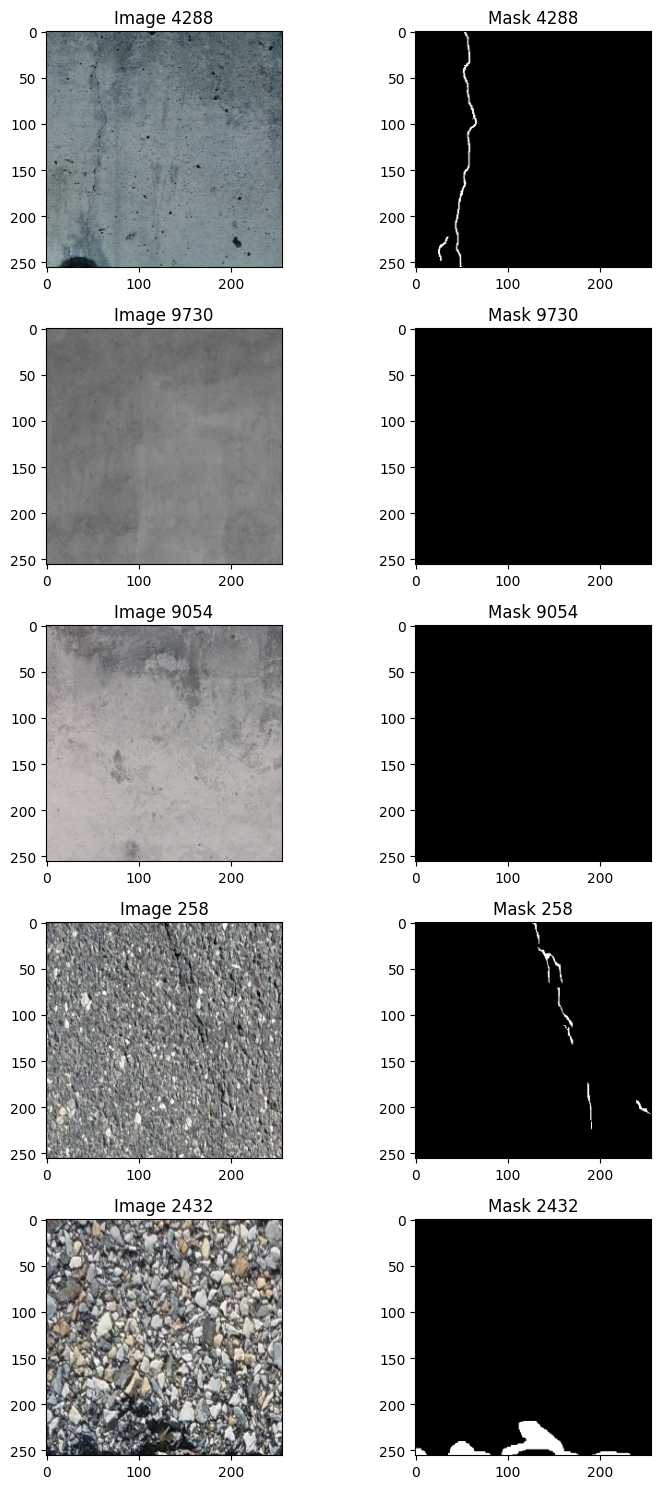

In [ ]:
import matplotlib.pyplot as plt
import random
image_dir = '/content/Conglomerate Concrete Crack Detection/Train/images'
mask_dir = '/content/Conglomerate Concrete Crack Detection/Train/masks'

def visualize_samples(image_dir, mask_dir, num_samples=5):

    image_paths = sorted([os.path.join(image_dir, fname) for fname in os.listdir(image_dir)])
    mask_paths = sorted([os.path.join(mask_dir, fname) for fname in os.listdir(mask_dir)])

    sample_indices=random.sample(range(len(image_paths)), num_samples)

    plt.figure(figsize=(8, num_samples * 3))

    for i, idx in enumerate(sample_indices):

        img, msk = load_image_mask(image_paths[idx], mask_paths[idx])

        plt.subplot(num_samples, 2, 2*i+1)

        plt.imshow(img)

        plt.title(f"Image {idx}")

        plt.subplot(num_samples, 2, 2*i+2)

        plt.imshow(msk, cmap = 'gray')

        plt.title(f"Mask {idx}")

    plt.tight_layout()

    plt.show()
visualize_samples(image_dir,mask_dir)

In [ ]:
def conv_block(inputs, num_filters):
    x = tf.keras.layers.Conv2D(num_filters, 3, padding = 'same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('leaky_relu')(x)
    x = tf.keras.layers.Dropout(rate = 0.5)(x)


    x = tf.keras.layers.Conv2D(num_filters, 3, padding = 'same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('leaky_relu')(x)
    x = tf.keras.layers.Dropout(rate = 0.5)(x)



    return x


def encoder_block(inputs, num_filters):
    x = conv_block(inputs, num_filters)
    p = tf.keras.layers.MaxPool2D((2, 2))(x)
    return x, p


def decoder_block(inputs, skip_features, num_filters):
    x = tf.keras.layers.Conv2DTranspose(num_filters, (2, 2), strides = 2, padding = 'same')(inputs)
    x = tf.keras.layers.Concatenate()([x, skip_features])
    x = conv_block(x, num_filters)
    return x

def build_unet(input_shape):
    inputs=tf.keras.layers.Input(shape=input_shape)

    s1,p1=encoder_block(inputs,32)
    s2,p2=encoder_block(p1,64)
    s3,p3=encoder_block(p2,128)
    s4,p4=encoder_block(p3,256)

    b1=conv_block(p4,512)

    d1=decoder_block(b1,s4,256)
    d2=decoder_block(d1,s3,128)
    d3=decoder_block(d2,s2,64)
    d4=decoder_block(d3,s1,32)

    outputs=tf.keras.layers.Conv2D(1,1,padding='same',activation='sigmoid')(d4)
    model=tf.keras.models.Model(inputs,outputs,name='U-Net')
    return model

input_shape=(256,256,3)
model=build_unet(input_shape)

In [ ]:
model.compile(loss='binary_crossentropy',optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),metrics=['accuracy'])
model.fit(train_dataset,epochs=2,validation_data=val_dataset)

Epoch 1/2


In [ ]:
def dice_loss(y_true,y_pred,smooth=1):
    y_true=tf.cast(y_true,tf.float32)
    y_pred=tf.cast(y_pred,tf.float32)

    intersection=tf.reduce_sum(y_true*y_pred)
    union=tf.reduce_sum(y_true)+tf.reduce_sum(y_pred)

    dice=(2.*intersection+smooth)/(union+smooth)
    return 1-dice

def bce_dice_loss(y_true,y_pred):
    bce=tf.keras.losses.BinaryCrossentropy()(y_true,y_pred)
    dice=dice_loss(y_true,y_pred)
    return bce+dice

def dice_coef(y_true,y_pred,smooth=1):
    y_true=tf.cast(y_true,tf.float32)
    y_pred=tf.cast(y_pred>0.5,tf.float32)

    intersection=tf.reduce_sum(y_true*y_pred)
    union=tf.reduce_sum(y_true)+tf.reduce_sum(y_pred)

    dice=(2.*intersection+smooth)/(union+smooth)
    return dice

model.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate = 0.0001),
    loss=bce_dice_loss,
    metrics=[dice_coef]
)

model.fit(train_dataset, epochs = 2, validation_data = val_dataset)